Sentiment Analysis Model using IMDB Movie Reviews

Vortex Tech AI & ML Internship – Week 4

Objective

The objective of this project is to build a Sentiment Analysis Model that classifies movie reviews as Positive or Negative using Natural Language Processing (NLP). The project includes text preprocessing, TF-IDF feature extraction, model training, evaluation, and prediction on custom sentences.

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----- -------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [5]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from nltk.corpus import stopwords

# Download English stopwords
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import sys
print(sys.executable)

%pip install nltk

c:\Users\User\AppData\Local\Programs\Python\Python314\python.exe
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached regex-2026.9.10-cp314-cp314-win_amd64.whl.metadata (41 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
Using cached nltk-3.10.3-py3-none-any.whl (1.8 MB)
Using cached regex-2026.9.10-cp314-cp314-win_amd64.whl (281 kB)
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)
Using cached tqdm-4.70.1-py3-none-any.whl (80 kB)

   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------------------------------------- 0/4 [tqdm]
   ---------- ----------------------------- 1/4 [regex]
   -------------------- ------------------- 2/4 [defusedxml]
   ------------------------------ --------- 3/4 [nl

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import nltk
print("NLTK version:", nltk.__version__)

nltk.download("stopwords")

NLTK version: 3.10.3


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

Load the Dataset

The IMDB Movie Reviews dataset contains 50,000 movie reviews with positive and negative sentiment labels. This dataset will be used to train a binary sentiment classification model.

In [12]:
import pandas as pd

df = pd.read_csv(r"IMDB Dataset.csv/IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Explore the Dataset

In this step, we will inspect the dataset by checking its size, column names, and basic information before preprocessing the text.

In [13]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

Dataset Shape: (50000, 2)

Column Names:
Index(['review', 'sentiment'], dtype='str')


Dataset Information and Missing Values

Before training the model, we should check whether the dataset contains missing values and inspect its overall structure.

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [15]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

Check Class Distribution

Before training the model, it is important to verify whether the dataset contains a balanced number of positive and negative reviews.

In [16]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

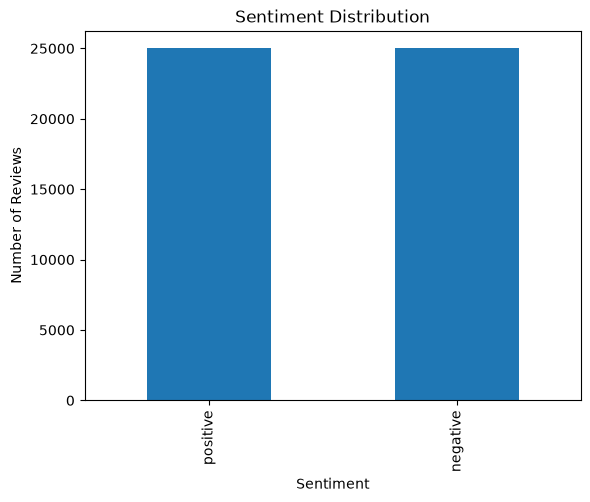

In [17]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

Observation

The dataset is perfectly balanced, with 25,000 positive and 25,000 negative reviews. A balanced dataset helps reduce bias during model training and allows the classifier to learn both sentiment classes equally.

Text Preprocessing

In this step, the text reviews are cleaned by converting them to lowercase, removing punctuation and special characters, and eliminating common English stopwords. This improves the quality of the text before feature extraction.

In [18]:
# English stopwords
stop_words = set(stopwords.words("english"))

# Text cleaning function
def clean_text(text):
    text = text.lower()                          # Convert to lowercase
    text = re.sub(r"[^a-zA-Z\s]", "", text)      # Remove punctuation & numbers
    words = text.split()                         # Tokenization
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    return " ".join(words)

In [19]:
df["clean_review"] = df["review"].apply(clean_text)

# Compare original and cleaned reviews
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


Label Encoding

The sentiment labels are converted into numerical values so that the machine learning model can process them. Here, positive = 1 and negative = 0.

In [20]:
# Convert sentiment labels into numbers
df["label"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

# Preview the result
df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


TF-IDF Feature Extraction

The cleaned text is converted into numerical features using TF-IDF (Term Frequency-Inverse Document Frequency). This technique gives higher importance to meaningful words while reducing the influence of very common words.

In [21]:
# Convert text into TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_review"])
y = df["label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (50000, 5000)


Train-Test Split

The dataset is divided into training and testing sets. The model learns from the training data (80%) and is evaluated on the testing data (20%) to measure its performance on unseen reviews.

In [22]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (40000, 5000)
Testing Data: (10000, 5000)


Train the Logistic Regression Model

Logistic Regression is a popular classification algorithm for binary sentiment analysis. It learns patterns from TF-IDF features and predicts whether a review is positive or negative.

In [23]:
# Create and train the model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Make Predictions

After training, the model predicts the sentiment of reviews in the testing dataset.

In [24]:
# Predict sentiments for test data
y_pred = model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


Model Evaluation

The trained model is evaluated using Accuracy, F1-score, Classification Report, and a Confusion Matrix to measure its performance on unseen data.

In [25]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.8873
F1-Score: 0.8896


In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



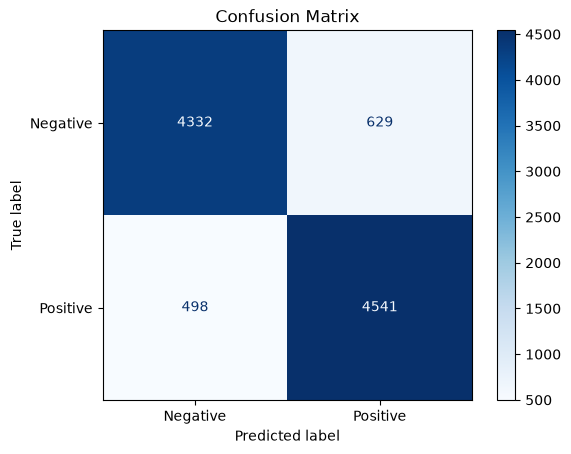

In [27]:
# Display confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

Evaluation Summary

The Logistic Regression model achieved high performance on the IMDB sentiment dataset. The accuracy and F1-score indicate that the model can effectively distinguish between positive and negative movie reviews, while the confusion matrix provides insight into correctly and incorrectly classified examples.

In [28]:
# Three custom test sentences
my_reviews = [
    "This was the best experience ever. I loved every moment.",
    "This movie was a complete waste of time.",
    "The acting was decent but the story became boring."
]

# Clean the sentences
clean_reviews = [clean_text(review) for review in my_reviews]

# Convert into TF-IDF features
X_new = vectorizer.transform(clean_reviews)

# Predict sentiment
predictions = model.predict(X_new)

# Display results
for review, pred in zip(my_reviews, predictions):
    sentiment = "Positive" if pred == 1 else "Negative"
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}\n")

Review: This was the best experience ever. I loved every moment.
Predicted Sentiment: Positive

Review: This movie was a complete waste of time.
Predicted Sentiment: Negative

Review: The acting was decent but the story became boring.
Predicted Sentiment: Negative



Final Summary

This project developed a Sentiment Analysis Model using the IMDB Movie Reviews dataset containing 50,000 labeled reviews. The text data was preprocessed by converting reviews to lowercase, removing punctuation and stopwords, and creating cleaned text. The cleaned reviews were transformed into numerical features using TF-IDF vectorization with 5,000 features. An 80/20 train-test split was applied, and a Logistic Regression classifier was trained on the processed data. The model was evaluated using Accuracy, F1-score, Classification Report, and a Confusion Matrix, achieving strong performance on unseen reviews. Finally, the trained model successfully predicted the sentiment of three custom-written sentences, demonstrating its ability to classify positive and negative text.